In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

print("OK")

OK


In [5]:
df = pd.read_parquet('../data/processed.parquet')
print(f"Размер: {df.shape}")
print(f"Диалогов: {df['dialogue_id'].nunique()}")
print(f"Доля is_end=1: {df['is_end'].mean():.3f}")
df.head()

Размер: (153983, 11)
Диалогов: 2000
Доля is_end=1: 0.088


,dialogue_id,turn_id,prefix_text,is_end,length_words,length_chars,last_word,ends_with_punct,has_question_word,last_pos,ends_with_prep
0,PMUL4398.json,0,i,0,1,1,i,0,0,PRON,0
1,PMUL4398.json,0,i need,0,2,6,need,0,0,VERB,0
2,PMUL4398.json,0,i need a,0,3,8,a,0,0,DET,0
3,PMUL4398.json,0,i need a place,0,4,14,place,0,0,NOUN,0
4,PMUL4398.json,0,i need a place to,0,5,17,to,0,0,PART,0


In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, groups=df['dialogue_id']))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train: {len(train_df):,} строк, {train_df['dialogue_id'].nunique()} диалогов")
print(f"Test:  {len(test_df):,} строк, {test_df['dialogue_id'].nunique()} диалогов")
print()

# Проверка: нет пересечений по dialogue_id
overlap = set(train_df['dialogue_id']) & set(test_df['dialogue_id'])
print(f"Пересечение диалогов: {len(overlap)}  (должно быть 0)")

# Проверка: баланс классов сохраняется в обоих сплитах
print(f"\nДоля is_end=1 в train: {train_df['is_end'].mean():.3f}")
print(f"Доля is_end=1 в test:  {test_df['is_end'].mean():.3f}")

Train: 122,667 строк, 1600 диалогов
Test:  31,316 строк, 400 диалогов

Пересечение диалогов: 0  (должно быть 0)

Доля is_end=1 в train: 0.088
Доля is_end=1 в test:  0.087


In [7]:
# Числовые и бинарные признаки (берем как есть)
NUMERIC_FEATURES = ['length_words', 'length_chars', 'ends_with_punct', 
                    'ends_with_prep', 'has_question_word']

# Категориальные (нужен one-hot encoding)
CATEGORICAL_FEATURES = ['last_pos']

# last_word оставим на потом (там много уникальных значений, нужен target encoding)

# Целевая переменная
y_train = train_df['is_end'].values
y_test = test_df['is_end'].values

# Признаки
X_train_raw = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test_raw = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

print(f"X_train: {X_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}")
print(f"\nТипы признаков:")
print(X_train_raw.dtypes)
print(f"\nУникальные POS-теги: {X_train_raw['last_pos'].nunique()}")
print(X_train_raw['last_pos'].value_counts())


X_train: (122667, 6)
X_test:  (31316, 6)

Типы признаков:
length_words         int64
length_chars         int64
ends_with_punct      int64
ends_with_prep       int64
has_question_word    int64
last_pos               str
dtype: object

Уникальные POS-теги: 17
last_pos
NOUN     18731
PRON     16661
VERB     16270
DET      12248
ADP      11921
AUX      10277
PROPN     7077
INTJ      6390
ADJ       4765
ADV       4673
PART      4173
NUM       3952
SCONJ     2781
CCONJ     2541
X          105
PUNCT       92
SYM         10
Name: count, dtype: int64


In [8]:
# OneHotEncoder превращает категорию "ADP" в столбец где 1 если ADP, иначе 0
# handle_unknown='ignore' — если в тесте появится POS которого не было в train, не падать
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Обучаем на train, применяем на оба сплита
ohe.fit(X_train_raw[CATEGORICAL_FEATURES])

# Получаем имена новых столбцов
ohe_columns = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
print(f"Создано {len(ohe_columns)} OHE-столбцов:")
print(list(ohe_columns))

# Применяем
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_raw[CATEGORICAL_FEATURES]),
    columns=ohe_columns,
    index=X_train_raw.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_raw[CATEGORICAL_FEATURES]),
    columns=ohe_columns,
    index=X_test_raw.index
)

# Собираем финальный X
X_train = pd.concat([X_train_raw[NUMERIC_FEATURES], X_train_ohe], axis=1)
X_test = pd.concat([X_test_raw[NUMERIC_FEATURES], X_test_ohe], axis=1)

print(f"\nИтоговая форма X_train: {X_train.shape}")
print(f"Столбцы: {list(X_train.columns)}")
X_train.head()

Создано 17 OHE-столбцов:
['last_pos_ADJ', 'last_pos_ADP', 'last_pos_ADV', 'last_pos_AUX', 'last_pos_CCONJ', 'last_pos_DET', 'last_pos_INTJ', 'last_pos_NOUN', 'last_pos_NUM', 'last_pos_PART', 'last_pos_PRON', 'last_pos_PROPN', 'last_pos_PUNCT', 'last_pos_SCONJ', 'last_pos_SYM', 'last_pos_VERB', 'last_pos_X']

Итоговая форма X_train: (122667, 22)
Столбцы: ['length_words', 'length_chars', 'ends_with_punct', 'ends_with_prep', 'has_question_word', 'last_pos_ADJ', 'last_pos_ADP', 'last_pos_ADV', 'last_pos_AUX', 'last_pos_CCONJ', 'last_pos_DET', 'last_pos_INTJ', 'last_pos_NOUN', 'last_pos_NUM', 'last_pos_PART', 'last_pos_PRON', 'last_pos_PROPN', 'last_pos_PUNCT', 'last_pos_SCONJ', 'last_pos_SYM', 'last_pos_VERB', 'last_pos_X']


,length_words,length_chars,ends_with_punct,ends_with_prep,has_question_word,last_pos_ADJ,last_pos_ADP,last_pos_ADV,last_pos_AUX,last_pos_CCONJ,last_pos_DET,last_pos_INTJ,last_pos_NOUN,last_pos_NUM,last_pos_PART,last_pos_PRON,last_pos_PROPN,last_pos_PUNCT,last_pos_SCONJ,last_pos_SYM,last_pos_VERB,last_pos_X
82,1,5,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
83,2,10,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,3,12,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
85,4,15,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86,5,23,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Печатает метрики модели и возвращает dict с результатами."""
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    
    print(f"\n=== {name} ===")
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}  (из названных 'конец' — доля реальных концов)")
    print(f"Recall:    {recall:.4f}  (из всех реальных концов — доля пойманных)")
    if auc is not None:
        print(f"ROC-AUC:   {auc:.4f}")
    
    print(f"\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=['не конец', 'конец']))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:")
    print(f"                  Predicted")
    print(f"                  не конец  конец")
    print(f"Actual не конец    {cm[0,0]:>6}  {cm[0,1]:>6}")
    print(f"Actual конец       {cm[1,0]:>6}  {cm[1,1]:>6}")
    
    return {'name': name, 'f1': f1, 'precision': precision, 
            'recall': recall, 'auc': auc}


results = []  # будем накапливать результаты всех моделей
print("Готово")

Готово


Baseline — простое правило: если префикс заканчивается на .?!, считаем что это конец реплики. Это нижняя планка — любая ML-модель должна её обходить.

In [15]:
# Baseline (ends_with_punct)
y_pred_baseline = X_test['ends_with_punct'].values.astype(int)
baseline_result = evaluate_model('Baseline (ends_with_punct)', y_test, y_pred_baseline)
results.append(baseline_result)


=== Baseline (ends_with_punct) ===
F1-score:  0.7686
Precision: 0.6629  (из названных 'конец' — доля реальных концов)
Recall:    0.9142  (из всех реальных концов — доля пойманных)

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.96      0.97     28599
       конец       0.66      0.91      0.77      2717

    accuracy                           0.95     31316
   macro avg       0.83      0.94      0.87     31316
weighted avg       0.96      0.95      0.96     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27336    1263
Actual конец          233    2484


In [18]:
# Logistic Regression

from sklearn.preprocessing import StandardScaler

# Стандартизация — LogReg чувствительна к масштабу признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' — компенсация дисбаланса классов (87% vs 13%)
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
lr.fit(X_train_scaled, y_train)

y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_proba_lr_train = lr.predict_proba(X_train_scaled)[:, 1]

print(f"LogReg обучилась за {lr.n_iter_[0]} итераций")

LogReg обучилась за 30 итераций


Стандартный порог 0.5 не оптимален при дисбалансе классов и class_weight='balanced'. Подбираем порог, максимизирующий F1, на train — иначе будет утечка данных в test.

Оптимальный порог по train: 0.83
F1 на train с этим порогом: 0.7853


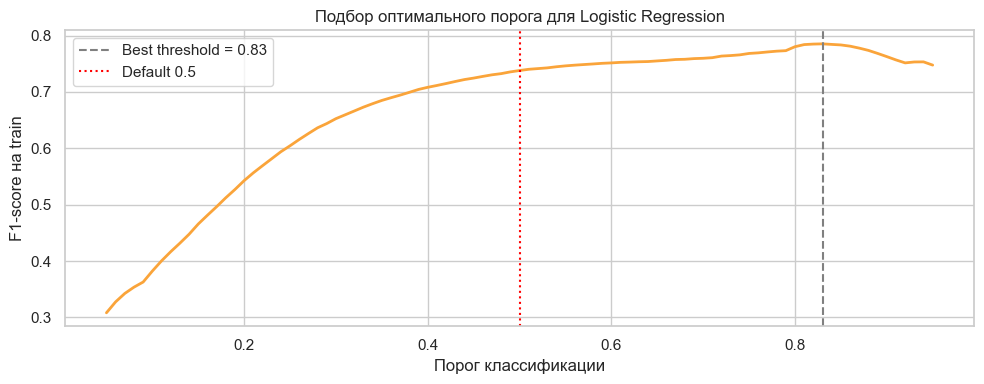

In [19]:
# Подбираем порог НА TRAIN (не на test — иначе утечка)
thresholds = np.linspace(0.05, 0.95, 91)
f1_by_threshold = [f1_score(y_train, (y_proba_lr_train > t).astype(int)) 
                   for t in thresholds]
best_threshold = thresholds[np.argmax(f1_by_threshold)]

print(f"Оптимальный порог по train: {best_threshold:.2f}")
print(f"F1 на train с этим порогом: {max(f1_by_threshold):.4f}")

# Визуализация: F1 как функция порога
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_by_threshold, color='#FAA43A', linewidth=2)
ax.axvline(best_threshold, color='gray', linestyle='--', 
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='red', linestyle=':', label='Default 0.5')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score на train')
ax.set_title('Подбор оптимального порога для Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/logreg_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
y_pred_lr = (y_proba_lr > best_threshold).astype(int)
lr_result = evaluate_model(
    f'Logistic Regression (threshold={best_threshold:.2f})',
    y_test, y_pred_lr, y_proba_lr
)
results.append(lr_result)


=== Logistic Regression (threshold=0.83) ===
F1-score:  0.7918
Precision: 0.7165  (из названных 'конец' — доля реальных концов)
Recall:    0.8848  (из всех реальных концов — доля пойманных)
ROC-AUC:   0.9726

Classification report:
              precision    recall  f1-score   support

    не конец       0.99      0.97      0.98     28599
       конец       0.72      0.88      0.79      2717

    accuracy                           0.96     31316
   macro avg       0.85      0.93      0.88     31316
weighted avg       0.97      0.96      0.96     31316

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     27648     951
Actual конец          313    2404


=== Топ-15 признаков по абсолютной величине коэффициента ===
        feature  coefficient
ends_with_punct     1.550040
   length_chars     0.885074
 last_pos_CCONJ    -0.547043
  last_pos_NOUN     0.475292
 last_pos_SCONJ    -0.378607
   last_pos_AUX    -0.359771
  last_pos_INTJ     0.331382
 last_pos_PROPN     0.325076
   last_pos_NUM     0.322958
  last_pos_PART    -0.268175
   length_words    -0.228936
   last_pos_ADP    -0.227367
 ends_with_prep    -0.227367
   last_pos_DET    -0.212947
  last_pos_VERB     0.069455


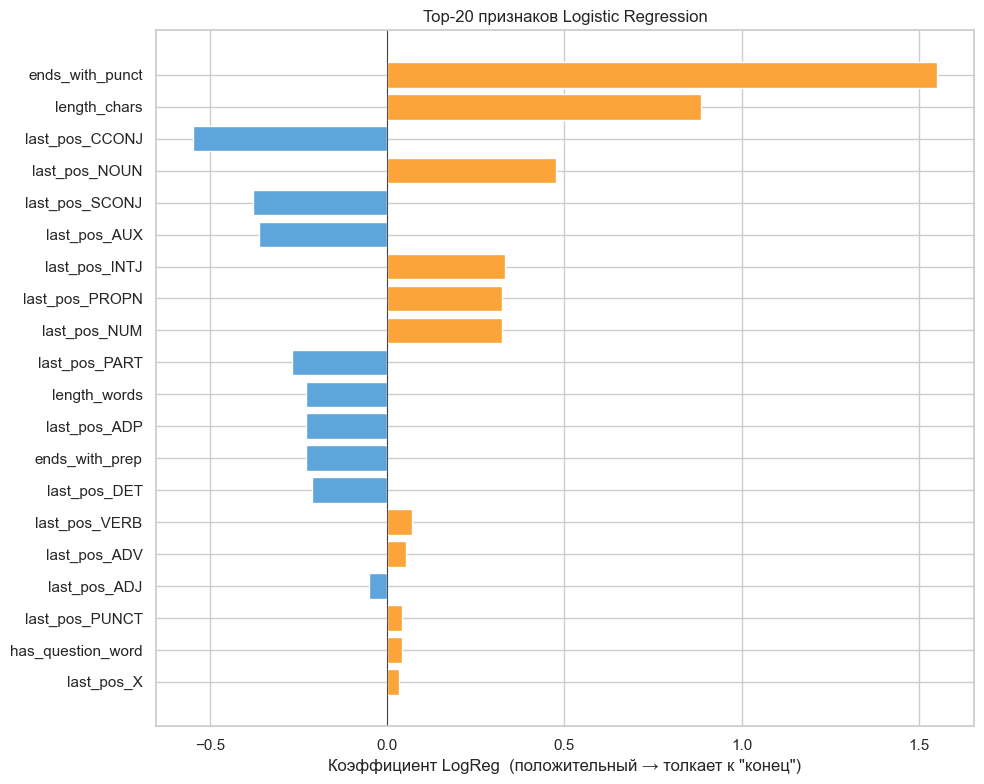

In [21]:
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=== Топ-15 признаков по абсолютной величине коэффициента ===")
print(feature_importance_lr.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top = feature_importance_lr.head(20)
colors = ['#FAA43A' if c > 0 else '#5DA5DA' for c in top['coefficient']]
ax.barh(top['feature'], top['coefficient'], color=colors)
ax.set_xlabel('Коэффициент LogReg  (положительный → толкает к "конец")')
ax.set_title('Top-20 признаков Logistic Regression')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

Положительные коэффициенты толкают к классу «конец», отрицательные — к «не конец». Картинка должна совпадать с выводами EDA: punct/length/NOUN/INTJ тянут к концу, ADP/DET/CCONJ тянут к середине.

In [22]:
results_df = pd.DataFrame(results)
print("=== Промежуточное сравнение моделей ===")
print(results_df.to_string(index=False))

=== Промежуточное сравнение моделей ===
                                name       f1  precision   recall      auc
          Baseline (ends_with_punct) 0.768564   0.662930 0.914244      NaN
Logistic Regression (threshold=0.83) 0.791831   0.716542 0.884799 0.972646
